In [7]:
import json
import pandas as pd
from collections import Counter

# File paths
WORDMAP_PATH = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
DATASET_PATH = '../dataset/caption_datasets/dataset_coco.json'

# Official COCO categories (normalized to match typical tokenization)
COCO_OBJECTS = {
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 
    'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 
    'kite', 'skateboard', 'surfboard', 'bottle', 'cup', 'fork', 'knife', 'spoon', 'bowl', 
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'pizza', 'donut', 'cake', 
    'chair', 'couch', 'bed', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 
    'scissors', 'toothbrush'
}

def get_filtered_training_stats():
    # Load raw captions
    with open(DATASET_PATH, 'r') as j:
        data = json.load(j)
    
    # Extract only tokens that are in our COCO_OBJECTS list
    train_tokens = [
        word 
        for img in data['images'] if img['split'] == 'train'
        for sentence in img['sentences']
        for word in sentence['tokens']
        if word in COCO_OBJECTS
    ]
    
    stats = Counter(train_tokens)
    df = pd.DataFrame(stats.items(), columns=['Object', 'Frequency']).sort_values('Frequency')
    
    return df

# Execute
df_obj_stats = get_filtered_training_stats()

print("--- Rarest Objects (Hardest to Detect) ---")
print(df_obj_stats.head(10).to_string(index=False))

print("\n--- Most Frequent Objects (Highest Bias) ---")
print(df_obj_stats.tail(10).to_string(index=False))

--- Rarest Objects (Hardest to Detect) ---
    Object  Frequency
   handbag         58
   toaster        221
    carrot        342
  backpack        503
     spoon        513
toothbrush        629
     donut        884
     apple       1017
      fork       1051
     mouse       1161

--- Most Frequent Objects (Highest Bias) ---
    Object  Frequency
     clock       6892
skateboard       7008
    toilet       7286
       bed       8291
     pizza       8776
       bus       8995
       cat      11701
       dog      12627
     train      12753
    person      17202


In [9]:
import sys
import os
import json
import torch

# Fix for imports if needed
sys.path.append(os.path.abspath(os.path.join('..')))
from caption import caption_image_beam_search

# Load Word Map
word_map_path = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
with open(word_map_path, 'r') as j:
    word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

# Device & Model Loading
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'

checkpoint = torch.load(checkpoint_path, map_location=str(device), weights_only=False)
decoder = checkpoint['decoder'].to(device).eval()
encoder = checkpoint['encoder'].to(device).eval()

print("Model and Word Map loaded successfully.")

Model and Word Map loaded successfully.


In [15]:
import pandas as pd

diagnostic_dir = "../dataset/my_test_images/"
# Added .webp to support your handbag2.webp
valid_extensions = ('.jpg', '.png', '.jpeg', '.webp')
diagnostic_files = [f for f in os.listdir(diagnostic_dir) if f.lower().endswith(valid_extensions)]

results_for_audit = []

print(f"Generating captions for {len(diagnostic_files)} diagnostic images...")

with torch.no_grad():
    for filename in diagnostic_files:
        fpath = os.path.join(diagnostic_dir, filename)
        
        # Inference using beam search (k=5)
        seq, _ = caption_image_beam_search(encoder, decoder, fpath, word_map, 5)
        
        # Decode
        caption_tokens = [rev_word_map[i] for i in seq if i not in 
                          {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        caption = " ".join(caption_tokens)
        
        results_for_audit.append({
            "filename": filename,
            "generated_caption": caption,
            "category": "", # Leave empty for manual audit
            "comment": ""
        })

df_audit = pd.DataFrame(results_for_audit)
df_audit.to_csv("exp_4_hallucination_analysis_raw.csv", index=False)

print("\nDONE. Results saved to 'hallucination_analysis_raw.csv'.")
display(df_audit)

Generating captions for 30 diagnostic images...

DONE. Results saved to 'hallucination_analysis_raw.csv'.


,filename,generated_caption,category,comment
0,backpack1.jpg,a man in a yellow vest is holding a suitcase,,
1,backpack2.jpg,a man carrying a backpack and a backpack,,
2,backpack3.jpg,a woman holding a cell phone in her hand,,
3,backpack4.jpg,a blue bag with a blue backpack on it,,
4,backpack5.jpg,a yellow suitcase sitting on a wooden floor,,
5,carrot1.jpg,a carrot that is sitting on a table,,
6,carrot2.jpg,a woman holding a donut in her mouth,,
7,carrot3.jpg,a person cutting carrots on a cutting board,,
8,carrot4.jpg,a close up of a person eating a carrot,,
9,carrot5.jpg,a close up of a plate of food with broccoli,,


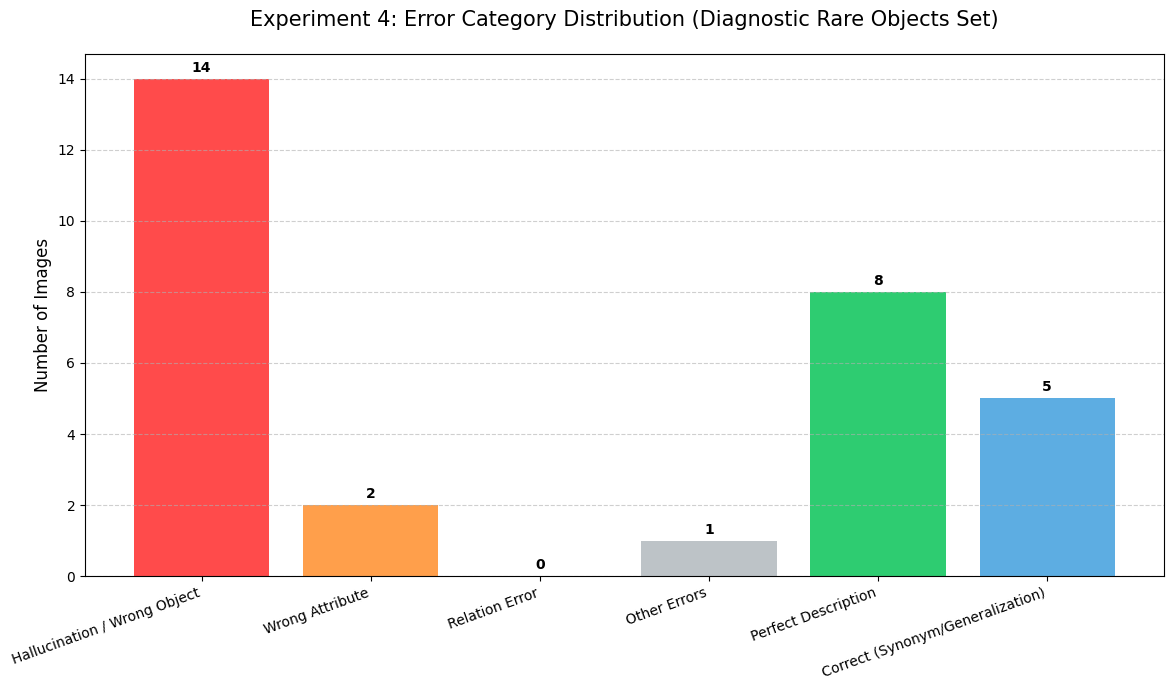

In [24]:
import matplotlib.pyplot as plt

# 1. Load data from the audit file
df_results = pd.read_csv("exp_4_hallucination_analysis_raw.csv")

# 2. Map categories to human-readable descriptions for the thesis
category_map = {
    'a': 'Hallucination / Wrong Object',
    'b': 'Wrong Attribute',
    'c': 'Relation Error',
    'd': 'Other Errors',
    'e': 'Perfect Description',
    'f': 'Correct (Synonym/Generalization)'
}

# 3. Process data: count occurrences and map names
# We ensure all categories exist in the index even if count is 0
stats = df_results['category'].value_counts().reindex(['a', 'b', 'c', 'd', 'e', 'f'], fill_value=0)
plot_data = pd.DataFrame({
    'Description': [category_map[k] for k in stats.index],
    'Count': stats.values
})

# 4. Visualization
plt.figure(figsize=(12, 7))
# Colors: Warm for errors, Blue for neutral, Green for success
colors = ['#ff4b4b', '#ff9f4b', '#f4d03f', '#bdc3c7', '#2ecc71', '#5dade2']

bars = plt.bar(plot_data['Description'], plot_data['Count'], color=colors)

# Professional styling
plt.title('Experiment 4: Error Category Distribution (Diagnostic Rare Objects Set)', fontsize=15, pad=20)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, int(yval), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()